#  Imports and basic setup

In [ ]:


import os
import numpy as np
import pandas as pd
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

import warnings
warnings.filterwarnings("ignore")


In [4]:
import os
print("Top level contents:")
for p in sorted(DATA_DIR.iterdir()):
    print("-", p.name)


Top level contents:
- fold1
- fold10
- fold2
- fold3
- fold4
- fold5
- fold6
- fold7
- fold8
- fold9
- UrbanSound8K.csv


In [6]:
from pathlib import Path

BASE = Path.home() / "Desktop" / "AI PROJECTS" / "SOUND"
print("BASE exists:", BASE.exists())
print("Top-level items in BASE:")
if BASE.exists():
    for p in sorted(BASE.iterdir()):
        print(" -", p.name)

print("\nSearching for any .csv under BASE (depth 5):")
if BASE.exists():
    csvs = list(BASE.rglob("*.csv"))
    print("Found", len(csvs), "csv files")
    for p in csvs[:30]:
        print(" -", p)
else:
    print("BASE folder doesn't exist on this machine.")


BASE exists: True
Top-level items in BASE:
 - fold1
 - fold10
 - fold2
 - fold3
 - fold4
 - fold5
 - fold6
 - fold7
 - fold8
 - fold9
 - UrbanSound8K.csv

Searching for any .csv under BASE (depth 5):
Found 1 csv files
 - C:\Users\jeeva\Desktop\AI PROJECTS\SOUND\UrbanSound8K.csv


# Load UrbanSound8K metadata and build file paths

In [ ]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.home() / "Desktop" / "AI PROJECTS" / "SOUND"

CSV_PATH = DATA_DIR / "UrbanSound8K.csv"   #  in root
AUDIO_DIR = DATA_DIR                       

meta = pd.read_csv(CSV_PATH)


print(meta.columns)
# Build the full path for each audio file
# build filepath: fold{fold}/slice_file_name
meta["filepath"] = meta.apply(lambda r: str(AUDIO_DIR / f"fold{r['fold']}" / r["slice_file_name"]), axis=1)

# sanity check
missing = (~pd.Series(meta["filepath"]).map(lambda p: Path(p).exists())).sum()
print("Missing audio files:", missing)

# Use folds 1–9 for training/validation, fold 10 as test
train_df = meta[meta["fold"] != 10].reset_index(drop=True)
test_df  = meta[meta["fold"] == 10].reset_index(drop=True)

train_df[["classID","class"]].drop_duplicates().sort_values("classID").head()


Index(['slice_file_name', 'fsID', 'start', 'end', 'salience', 'fold',
       'classID', 'class'],
      dtype='object')
Missing audio files: 0


,classID,class
13,0,air_conditioner
439,1,car_horn
1,2,children_playing
0,3,dog_bark
146,4,drilling


#  Audio loading and tabular feature extraction 

In [ ]:
SR = 22050
DURATION = 4.0
MAX_LEN = int(SR * DURATION)

#Load audio, resample, and either pad or trim to a fixed length.
def load_audio_fixed(path, sr=SR, max_len=MAX_LEN):
    y, _ = librosa.load(path, sr=sr, mono=True)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]
    return y

def extract_features(y, sr=SR, n_mfcc=40):
    # Frame-level features
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    def agg(F):
        return np.hstack([F.mean(axis=1), F.std(axis=1)])

    feat = np.hstack([agg(mfcc), agg(chroma), agg(contrast)])
    mfcc_mean = mfcc.mean(axis=1)  # for clustering
    return feat.astype(np.float32), mfcc_mean.astype(np.float32)


def make_feature_names(n_mfcc=40):
    mfcc_names = [f"mfcc_mean_{i}" for i in range(n_mfcc)] + [f"mfcc_std_{i}" for i in range(n_mfcc)]
    chroma_names = [f"chroma_mean_{i}" for i in range(12)] + [f"chroma_std_{i}" for i in range(12)]
    # spectral_contrast has 7 bands by default
    contrast_names = [f"contrast_mean_{i}" for i in range(7)] + [f"contrast_std_{i}" for i in range(7)]
    return mfcc_names + chroma_names + contrast_names

FEATURE_NAMES = make_feature_names(n_mfcc=40)
len(FEATURE_NAMES)


118

# Build and cache tabular feature matrices for all clips

In [ ]:
CACHE_DIR = Path("./cache_urbansound")
CACHE_DIR.mkdir(exist_ok=True)
TAB_CACHE = CACHE_DIR / "tabular_features.npz"
#Loop over a dataframe of filepaths and build
# tabular feature arrays
#KEEPS TRACK OF BAD FILES
def build_tabular(df):
    X_list, mfcc_list = [], []
    bad = 0
    for p in df["filepath"].tolist():
        try:
            y = load_audio_fixed(p)
            feat, mfcc_mean = extract_features(y)
            X_list.append(feat)
            mfcc_list.append(mfcc_mean)
        except Exception:
            bad += 1
            X_list.append(np.zeros(len(FEATURE_NAMES), dtype=np.float32))
            mfcc_list.append(np.zeros(40, dtype=np.float32))
    return np.vstack(X_list), np.vstack(mfcc_list), bad

if TAB_CACHE.exists():
    data = np.load(TAB_CACHE, allow_pickle=True)
    X_train, mfcc_train = data["X_train"], data["mfcc_train"]
    X_test,  mfcc_test  = data["X_test"],  data["mfcc_test"]
    y_train, y_test = data["y_train"], data["y_test"]
else:
    X_train, mfcc_train, bad_tr = build_tabular(train_df)
    X_test,  mfcc_test,  bad_te = build_tabular(test_df)
    y_train = train_df["class"].values
    y_test  = test_df["class"].values
    np.savez(TAB_CACHE,
             X_train=X_train, mfcc_train=mfcc_train, y_train=y_train,
             X_test=X_test,   mfcc_test=mfcc_test,   y_test=y_test)
    print("Bad files:", bad_tr, bad_te)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


Bad files: 0 0
(7895, 118) (837, 118) (7895,) (837,)


# Classical ML models: SVM, Random Forest, XGBoost

SVM: accuracy=0.7742, weighted_f1=0.7724
                  precision    recall  f1-score   support

 air_conditioner     0.8202    0.7300    0.7725       100
        car_horn     0.8235    0.8485    0.8358        33
children_playing     0.7302    0.9200    0.8142       100
        dog_bark     0.6579    0.7500    0.7009       100
        drilling     0.7935    0.7300    0.7604       100
   engine_idling     0.8788    0.6237    0.7296        93
        gun_shot     0.8571    0.9375    0.8955        32
      jackhammer     0.8165    0.9271    0.8683        96
           siren     0.6125    0.5904    0.6012        83
    street_music     0.8804    0.8100    0.8438       100

        accuracy                         0.7742       837
       macro avg     0.7871    0.7867    0.7822       837
    weighted avg     0.7811    0.7742    0.7724       837



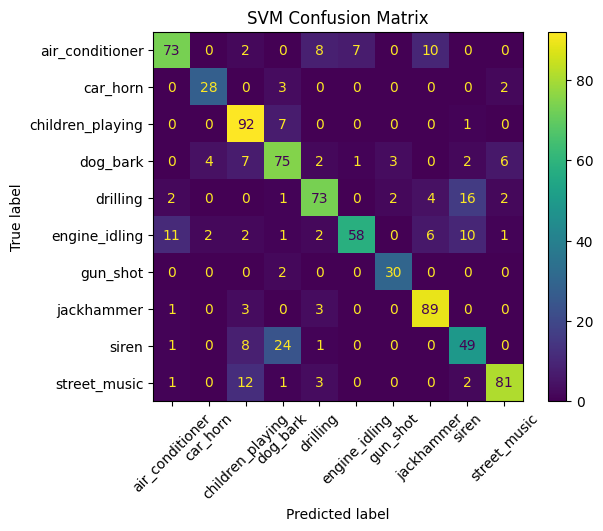

RandomForest: accuracy=0.7682, weighted_f1=0.7660
                  precision    recall  f1-score   support

 air_conditioner     0.7143    0.7500    0.7317       100
        car_horn     0.9615    0.7576    0.8475        33
children_playing     0.5762    0.8700    0.6932       100
        dog_bark     0.7629    0.7400    0.7513       100
        drilling     0.7979    0.7500    0.7732       100
   engine_idling     0.8387    0.5591    0.6710        93
        gun_shot     0.8205    1.0000    0.9014        32
      jackhammer     0.7949    0.9688    0.8732        96
           siren     0.9388    0.5542    0.6970        83
    street_music     0.8660    0.8400    0.8528       100

        accuracy                         0.7682       837
       macro avg     0.8072    0.7790    0.7792       837
    weighted avg     0.7908    0.7682    0.7660       837



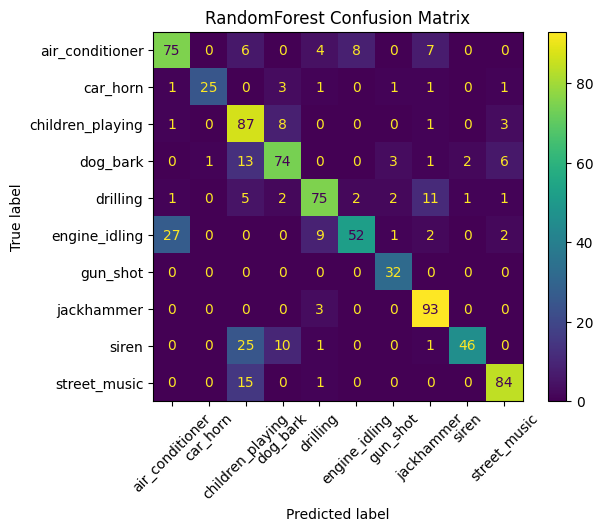

XGBoost: accuracy=0.7718, weighted_f1=0.7700
                  precision    recall  f1-score   support

 air_conditioner     0.7387    0.8200    0.7773       100
        car_horn     0.8333    0.7576    0.7937        33
children_playing     0.6000    0.8700    0.7102       100
        dog_bark     0.7812    0.7500    0.7653       100
        drilling     0.7959    0.7800    0.7879       100
   engine_idling     0.9474    0.5806    0.7200        93
        gun_shot     0.8108    0.9375    0.8696        32
      jackhammer     0.7850    0.8750    0.8276        96
           siren     0.8070    0.5542    0.6571        83
    street_music     0.8586    0.8500    0.8543       100

        accuracy                         0.7718       837
       macro avg     0.7958    0.7775    0.7763       837
    weighted avg     0.7901    0.7718    0.7700       837



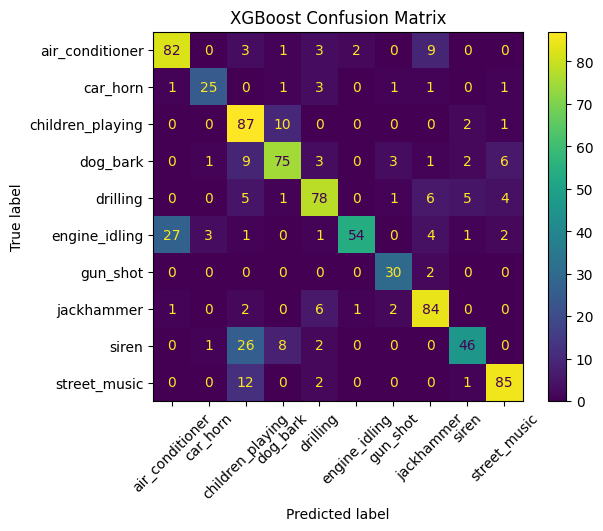

,accuracy,weighted_f1
SVM,0.774194,0.772426
XGB,0.771804,0.769963
RF,0.768220,0.765961


In [ ]:
label_order = sorted(meta["class"].unique())
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    acc = accuracy_score(y_te, pred)
    f1w = f1_score(y_te, pred, average="weighted")
    print(f"{name}: accuracy={acc:.4f}, weighted_f1={f1w:.4f}")
    print(classification_report(y_te, pred, digits=4))
    cm = confusion_matrix(y_te, pred, labels=label_order)
    ConfusionMatrixDisplay(cm, display_labels=label_order).plot(xticks_rotation=45, values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    return {"model": model, "acc": acc, "f1w": f1w, "pred": pred, "cm": cm}

# 1) SVM
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced"))
])

# 2) Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

# 3) XGBoost
le = LabelEncoder()
y_train_id = le.fit_transform(y_train)
y_test_id  = le.transform(y_test)

xgb_clf = xgb.XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

results = {}
results["SVM"] = eval_model("SVM", svm, X_train, y_train, X_test, y_test)
results["RF"]  = eval_model("RandomForest", rf, X_train, y_train, X_test, y_test)


# XGBoost training + evaluation
xgb_clf.fit(X_train, y_train_id)
xgb_pred_id = np.argmax(xgb_clf.predict_proba(X_test), axis=1)
xgb_pred = le.inverse_transform(xgb_pred_id)
acc = accuracy_score(y_test, xgb_pred)
f1w = f1_score(y_test, xgb_pred, average="weighted")
print(f"XGBoost: accuracy={acc:.4f}, weighted_f1={f1w:.4f}")
print(classification_report(y_test, xgb_pred, digits=4))
cm = confusion_matrix(y_test, xgb_pred, labels=label_order)
ConfusionMatrixDisplay(cm, display_labels=label_order).plot(xticks_rotation=45, values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.show()
results["XGB"] = {"model": xgb_clf, "acc": acc, "f1w": f1w, "pred": xgb_pred, "cm": cm}

# Small comparison table for the three classical models
pd.DataFrame({k: {"accuracy": v["acc"], "weighted_f1": v["f1w"]} for k,v in results.items()}).T.sort_values("weighted_f1", ascending=False)


# Feature importance

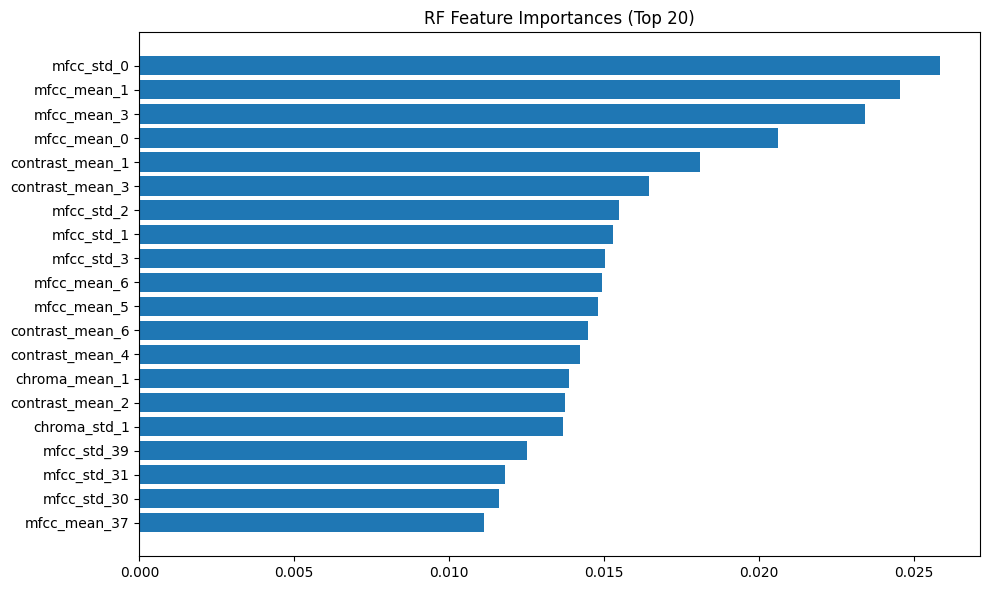

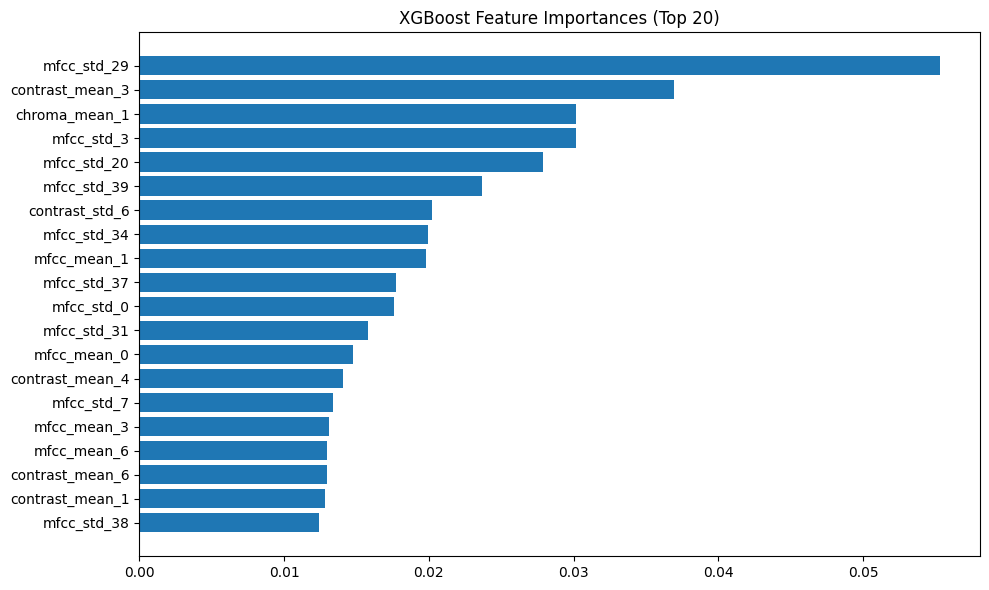

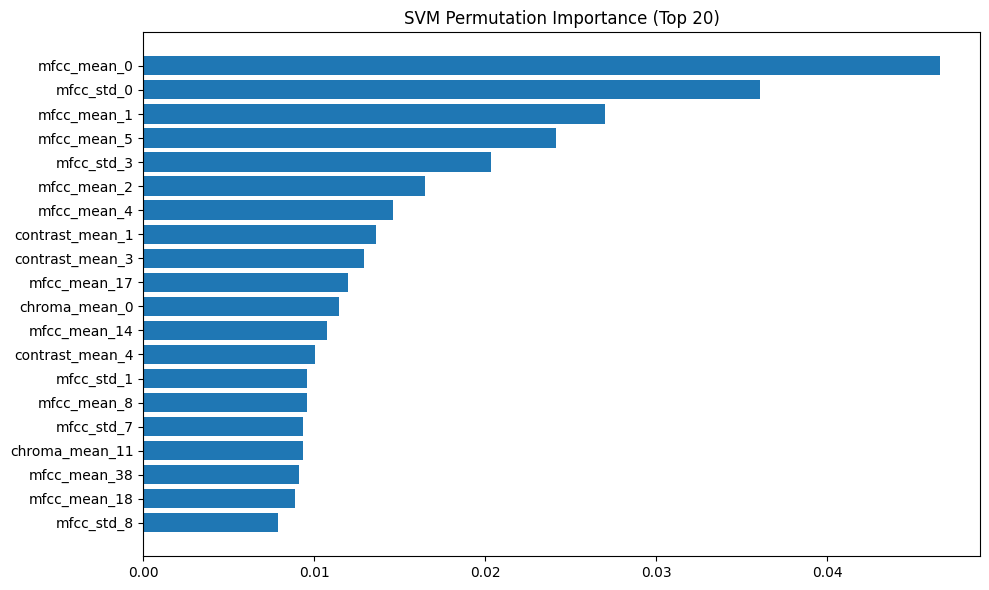

In [ ]:
def plot_top_importances(importances, names, topk=20, title="Feature Importances"):
    idx = np.argsort(importances)[::-1][:topk]
    plt.figure(figsize=(10, 6))
    plt.barh(np.array(names)[idx][::-1], importances[idx][::-1])
    plt.title(title)
    plt.tight_layout()
    plt.show()

# RF built-in
plot_top_importances(rf.feature_importances_, FEATURE_NAMES, title="RF Feature Importances (Top 20)")

# XGB built-in gain-based via feature_importances
plot_top_importances(xgb_clf.feature_importances_, FEATURE_NAMES, title="XGBoost Feature Importances (Top 20)")

# Permutation importance for SVM (can be slower)
perm = permutation_importance(results["SVM"]["model"], X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1)
plot_top_importances(perm.importances_mean, FEATURE_NAMES, title="SVM Permutation Importance (Top 20)")


# 7. SHAP analysis for XGBoost

100%|===================| 5999/6000 [40:01<00:00]        

X: (600, 118) SHAP: (600, 118, 10)


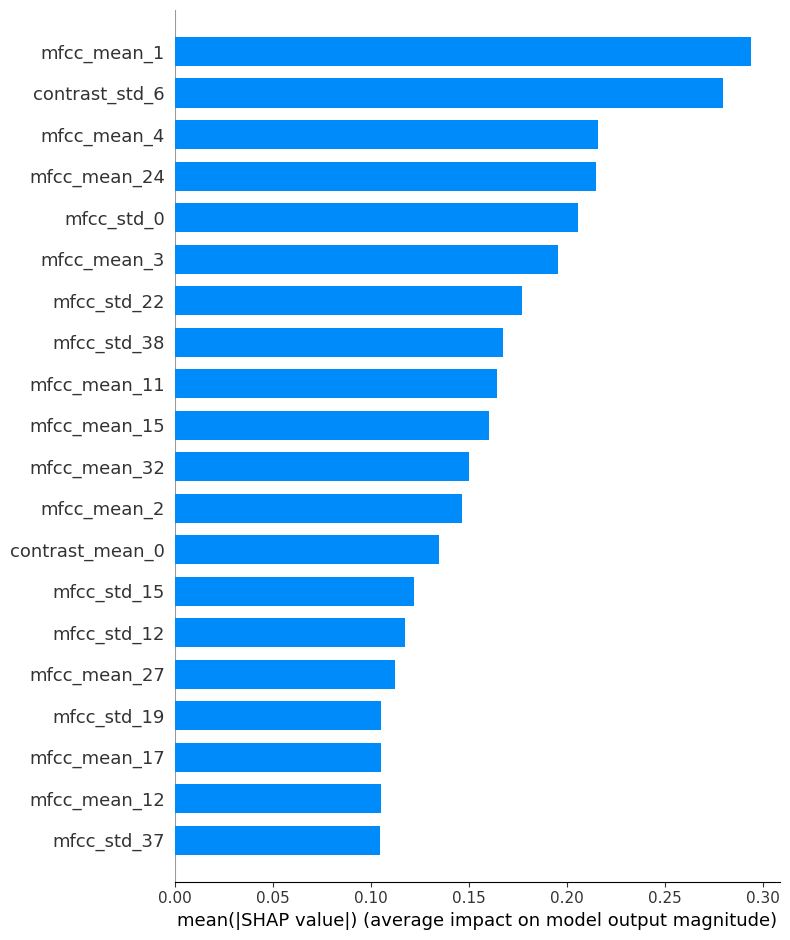

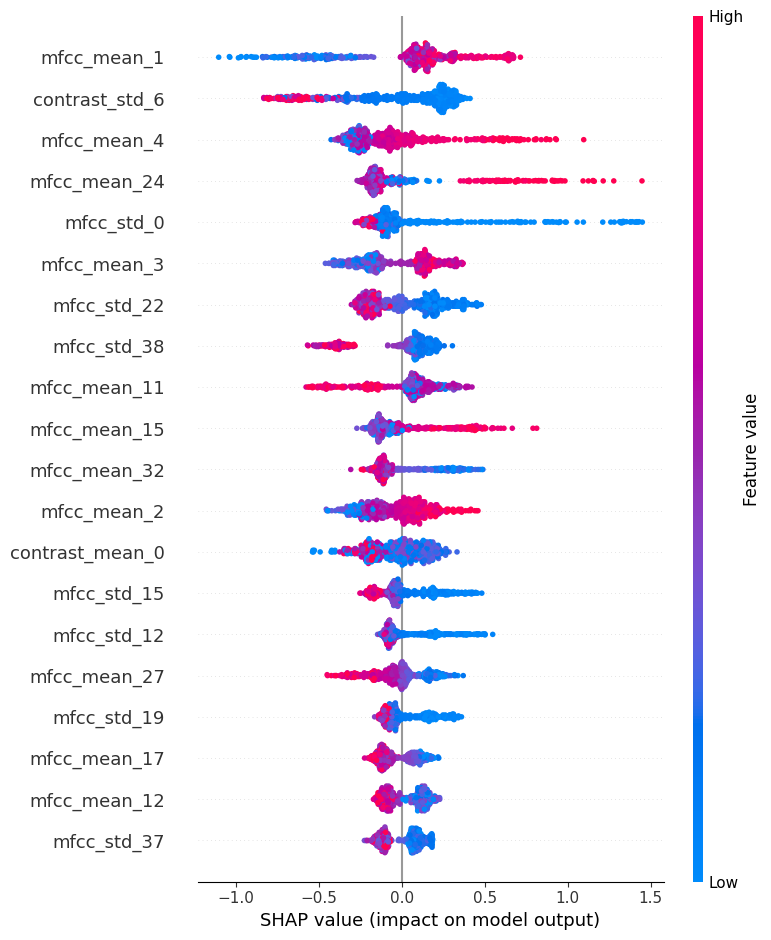

In [ ]:
import numpy as np
import pandas as pd
import shap


X_bg_df = pd.DataFrame(X_bg, columns=FEATURE_NAMES)
X_te_df = pd.DataFrame(X_te_small, columns=FEATURE_NAMES)

# TreeExplainer understands gradient-boosted trees
explainer = shap.TreeExplainer(xgb_clf, data=X_bg_df)

# New SHAP API returns an Explanation object
sv = explainer(X_te_df)
vals = sv.values  

print("X:", X_te_df.shape, "SHAP:", vals.shape)

class_i = 0  

# Pick the right slice for multiclass
if vals.ndim == 3:
    vals_c = vals[:, :, class_i]             
    vals_c = vals                             

# Handle the “extra bias column” case
X_plot = X_te_df
names_plot = FEATURE_NAMES
if vals_c.shape[1] == X_te_df.shape[1] + 1:
    vals_c = vals_c[:, :-1]
    # keep X_plot the same
    names_plot = FEATURE_NAMES[:vals_c.shape[1]]

# Bar summary  beeswarm
shap.summary_plot(vals_c, X_plot.iloc[:, :vals_c.shape[1]], feature_names=names_plot, plot_type="bar", show=True)
shap.summary_plot(vals_c, X_plot.iloc[:, :vals_c.shape[1]], feature_names=names_plot, show=True)


# CNN on log-mel spectrograms (Keras/TensorFlow)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

N_MELS = 64  # number of mel bands
HOP = 512       # hop length for STFT

def logmel(y, sr=SR, n_mels=N_MELS, hop_length=HOP):
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    S_db = librosa.power_to_db(S, ref=np.max)
    # normalize to roughly 0..1
    S_db = (S_db - S_db.min()) / (S_db.max() - S_db.min() + 1e-9)
    return S_db.astype(np.float32)

# Keras Sequence that streams log-mel spectrograms from disk.
#  This avoids loading everything into memory at once. 

class UrbanSoundSequence(tf.keras.utils.Sequence):
    def __init__(self, df, label_encoder, batch_size=32, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.le = label_encoder
        self.bs = batch_size
        self.shuffle = shuffle
        self.idx = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.bs))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.idx)

    def __getitem__(self, i):
        batch_idx = self.idx[i*self.bs:(i+1)*self.bs]
        batch = self.df.iloc[batch_idx]
        X, y = [], []
        for p, lbl in zip(batch["filepath"].tolist(), batch["class"].tolist()):
            audio = load_audio_fixed(p)
            spec = logmel(audio)  # [n_mels, time]
            X.append(spec[..., np.newaxis])  # add channel
            y.append(self.le.transform([lbl])[0])
        return np.stack(X), tf.keras.utils.to_categorical(np.array(y), num_classes=len(self.le.classes_))

# Make a validation split from train_df (folds 1-9)
tr_df, va_df = train_test_split(train_df, test_size=0.15, random_state=42, stratify=train_df["class"])
cnn_le = LabelEncoder().fit(train_df["class"].values)

train_seq = UrbanSoundSequence(tr_df, cnn_le, batch_size=32, shuffle=True)
val_seq   = UrbanSoundSequence(va_df, cnn_le, batch_size=32, shuffle=False)
test_seq  = UrbanSoundSequence(test_df, cnn_le, batch_size=32, shuffle=False)

# Infer input shape from one batch
xb, yb = train_seq[0]
inp_shape = xb.shape[1:]
inp_shape


(64, 173, 1)

In [ ]:
def make_cnn(input_shape, n_classes):

    #Simple 2D CNN for log-mel spectrogram classification.
    x_in = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(x_in)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPool2D((2,2))(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation="softmax")(x)

    model = models.Model(x_in, out)
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

cnn = make_cnn(inp_shape, len(cnn_le.classes_))
cnn.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃ Layer (type)            ┃ Output Shape      ┃   Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ input_layer             │ (None, 64, 173,   │         0 │
│ (InputLayer)            │ 1)                │           │
├─────────────────────────┼───────────────────┼───────────┤
│ conv2d (Conv2D)         │ (None, 64, 173,   │       320 │
│                         │ 32)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ batch_normalization     │ (None, 64, 173,   │       128 │
│ (BatchNormalization)    │ 32)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ max_pooling2d           │ (None, 32, 86,    │         0 │
│ (MaxPooling2D)          │ 32)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ conv2d_1 (Conv2D)       │ (None, 32, 86,    │    18,496 │
│                         │ 64)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ batch_normalization_1   │ (None, 32, 86,    │       256 │
│ (BatchNormalization)    │ 64)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ max_pooling2d_1         │ (None, 16, 43,    │         0 │
│ (MaxPooling2D)          │ 64)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ dropout (Dropout)       │ (None, 16, 43,    │         0 │
│                         │ 64)               │           │
├─────────────────────────┼───────────────────┼───────────┤
│ conv2d_2 (Conv2D)       │ (None, 16, 43,    │    73,856 │
│                         │ 128)              │           │
├─────────────────────────┼───────────────────┼───────────┤
│ batch_normalization_2   │ (None, 16, 43,    │       512 │
│ (BatchNormalization)    │ 128)              │           │
├─────────────────────────┼───────────────────┼───────────┤
│ global_average_pooling… │ (None, 128)       │         0 │
│ (GlobalAveragePooling2… │                   │           │
├─────────────────────────┼───────────────────┼───────────┤
│ dense (Dense)           │ (None, 128)       │    16,512 │
├─────────────────────────┼───────────────────┼───────────┤
│ dropout_1 (Dropout)     │ (None, 128)       │         0 │
├─────────────────────────┼───────────────────┼───────────┤
│ dense_1 (Dense)         │ (None, 10)        │     1,290 │
└─────────────────────────┴───────────────────┴───────────┘

 Total params: 111,370 (435.04 KB)

 Trainable params: 110,922 (433.29 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 193s 902ms/step - accuracy: 0.4361 - loss: 1.5739 - val_accuracy: 0.1764 - val_loss: 2.8025 - learning_rate: 0.0010
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 197s 880ms/step - accuracy: 0.6079 - loss: 1.0946 - val_accuracy: 0.1392 - val_loss: 2.9914 - learning_rate: 0.0010
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 189s 903ms/step - accuracy: 0.7104 - loss: 0.8663 - val_accuracy: 0.3063 - val_loss: 2.3963 - learning_rate: 0.0010
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 189s 898ms/step - accuracy: 0.7641 - loss: 0.6974 - val_accuracy: 0.5696 - val_loss: 1.5823 - learning_rate: 0.0010
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 187s 891ms/step - accuracy: 0.8116 - loss: 0.5805 - val_accuracy: 0.2886 - val_loss: 6.0207 - learning_rate: 0.0010
Epoch 6/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 188s 895ms/step - accuracy: 0.8311 - loss: 0.5233 - val_accuracy: 0.5527 - val_loss: 1.9127 - learning_rate: 0.0010
Epoch 7/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 189s 898ms/step - accura

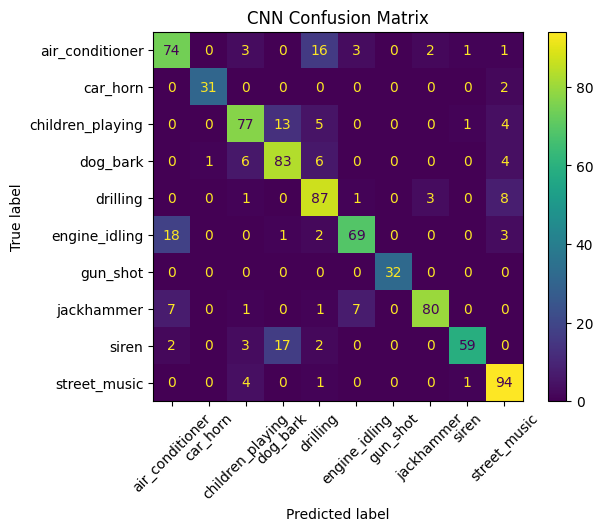

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True, monitor="val_accuracy"),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5, monitor="val_loss"),
]

hist = cnn.fit(train_seq, validation_data=val_seq, epochs=30, callbacks=callbacks, verbose=1)

# Evaluate on fold10 test
probs = cnn.predict(test_seq, verbose=0)
pred_id = probs.argmax(axis=1)
true_id = np.concatenate([test_seq[i][1].argmax(axis=1) for i in range(len(test_seq))])

pred_lbl = cnn_le.inverse_transform(pred_id)
true_lbl = cnn_le.inverse_transform(true_id)

acc = accuracy_score(true_lbl, pred_lbl)
f1w = f1_score(true_lbl, pred_lbl, average="weighted")
print(f"CNN: accuracy={acc:.4f}, weighted_f1={f1w:.4f}")
print(classification_report(true_lbl, pred_lbl, digits=4))

cm = confusion_matrix(true_lbl, pred_lbl, labels=label_order)
ConfusionMatrixDisplay(cm, display_labels=label_order).plot(xticks_rotation=45, values_format="d")
plt.title("CNN Confusion Matrix")
plt.show()


# 10. Visualise some example log-mel spectrograms

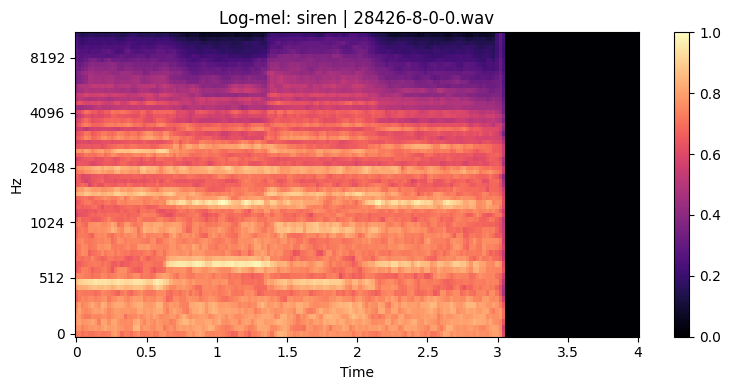

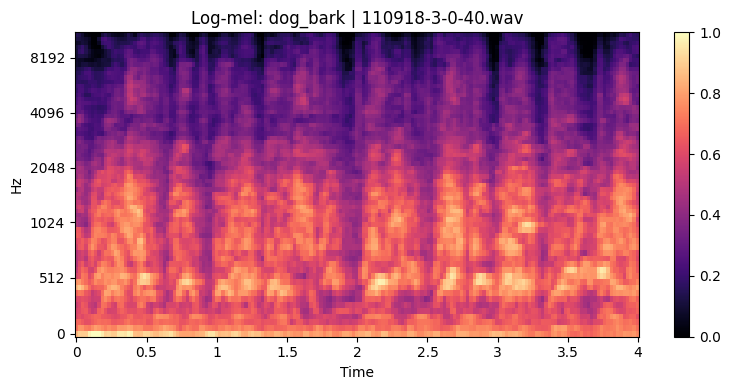

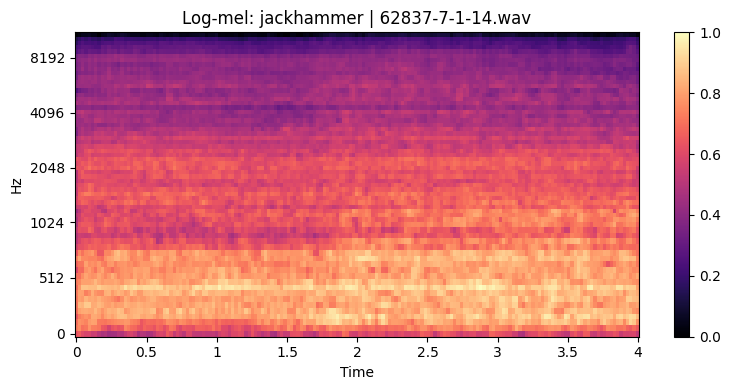

In [17]:
import random

def show_random_spectrogram(df, class_name=None):
    if class_name is None:
        row = df.sample(1, random_state=np.random.randint(10_000)).iloc[0]
    else:
        row = df[df["class"] == class_name].sample(1, random_state=np.random.randint(10_000)).iloc[0]
    y = load_audio_fixed(row["filepath"])
    S = logmel(y)
    plt.figure(figsize=(8,4))
    librosa.display.specshow(S, x_axis="time", y_axis="mel", hop_length=HOP, sr=SR)
    plt.title(f"Log-mel: {row['class']} | {Path(row['filepath']).name}")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

for c in ["siren", "dog_bark", "jackhammer"]:
    if c in meta["class"].unique():
        show_random_spectrogram(meta, c)


 # Unsupervised clustering with KMeans on MFCC means

  File "C:\Users\jeeva\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\jeeva\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jeeva\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jeeva\anaconda3\Lib\subprocess.

KMeans ARI: 0.116761751586487
KMeans NMI: 0.23947676231780746
KMeans mapped accuracy: 0.3070489844683393


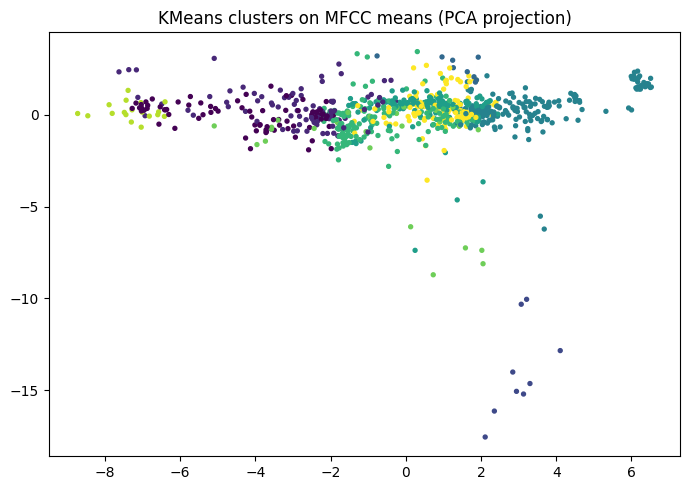

In [ ]:
# Standardize MFCC means Vectors
scaler = StandardScaler()
Z_train = scaler.fit_transform(mfcc_train)
Z_test  = scaler.transform(mfcc_test)

k = len(label_order)
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
cl_te = kmeans.fit_predict(Z_train)  # fit on train folds

# predict clusters for test
cl_test = kmeans.predict(Z_test)

# ARI/NMI (need numeric true labels)
true_test_id = LabelEncoder().fit(label_order).transform(y_test)

ari = adjusted_rand_score(true_test_id, cl_test)
nmi = normalized_mutual_info_score(true_test_id, cl_test)
print("KMeans ARI:", ari)
print("KMeans NMI:", nmi)

# Map clusters to true labels using Hungarian algorithm
C = confusion_matrix(true_test_id, cl_test, labels=np.arange(k))

row_ind, col_ind = linear_sum_assignment(-C)
mapping = {cluster: cls for cls, cluster in zip(row_ind, col_ind)}

mapped_pred = np.array([mapping[c] for c in cl_test])
cluster_acc = (mapped_pred == true_test_id).mean()
print("KMeans mapped accuracy:", cluster_acc)

# Visualize clustering with PCA
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z_test)

plt.figure(figsize=(7,5))
plt.scatter(Z2[:,0], Z2[:,1], c=cl_test, s=8)
plt.title("KMeans clusters on MFCC means (PCA projection)")
plt.tight_layout()
plt.show()


# Final comparison of all models

In [19]:
rows = []
for name, r in results.items():
    rows.append({"model": name, "accuracy": r["acc"], "weighted_f1": r["f1w"]})
rows.append({"model": "CNN", "accuracy": acc, "weighted_f1": f1w})
pd.DataFrame(rows).sort_values("weighted_f1", ascending=False)


,model,accuracy,weighted_f1
3,CNN,0.819594,0.820039
0,SVM,0.774194,0.772426
2,XGB,0.771804,0.769963
1,RF,0.768220,0.765961


# SUMMARY 

This tasks investigates multiple machine-learning approaches for environmental sound classification using the UrbanSound8K dataset. The pipeline starts by loading each audio clips at a fixed 22.05 khz ratio and padding or trimming is performed on it . From each clip The system extracts a variety of tabular audio features, such as spectral contrast, chroma, and MFCC means and standard deviations from each clip. The average spectral shape, timbre and energy distribution of each sound class are succinctly described by these combined statistics.

An RBF-kernel SVM, a Random Forest, and an XGBoost classifier were the three traditional models that were assessed. The findings demonstrate that all three models function similarly, with weighted F1-scores ranging from 0.766 to 0.772 and accuracies between 0.768 and 0.774. Out of all the classical models, the SVM performed the best.

Confusion matrix analysis showed that while more spectrally overlapping categories like engine_idling and siren showed lower recall classes than with with highly distinct acoustic profiles—like gun_shot, jackhammer and children_playing—were generally easier to classify.

The CNN achieved 0.8196 accuracy and 0.8200 weighted F1 which shows that The model can fully capture temporal and harmonic structure that the tabular features are unable to capture by learning from frequency images.

MFCC means and variances were consistently identified as the most significant predictors in the classical models .With an ARI of 0.1167, NMI of 0.2395, and mapped accuracy of only 0.3070, unsupervised clustering using K-Means performed poorly showing that class boundaries in environmental sounds are difficult to recover without labels.